<div style="width: 100%; text-align: center; margin-bottom: 20px;">
  <img src="cabecalho_branco.jpg" alt="Cabeçalho" style="max-width: 100%; height: auto;">
</div>

# 2.2 - Amostras de Tamanho Variável

Autor: **Carlos Gabriel de Oliveira Campos**

Professor Dr. **Daniel Roberto Cassar**

---

## População e Amostras

Na estatística, a *população* e a *amostra* de dados são conceitos fundamentais, mas que podem ser facilmente confundidos. Compreendê-los é crítico para realizar abordagens em que se faz necessária a distinção desses termos para a interpretação correta de dados.

A população consiste do conjunto de *todas* as observações referentes a um conjunto de dados. Ou seja, se uma tabela possui informações sobre $N$ observações, a totalidade desses registros compõe a população. Já a amostra é um subconjunto da população que é explorado para realizar *inferências* sobre a população.

### Qual devo analisar?

"Os dados da população são usados quando sua pergunta de pesquisa exige isso, ou quando você tem acesso a dados de todos os membros da população. Geralmente, é fácil coletar dados de toda a população apenas quando ela é pequena, acessível e cooperativa.

Exemplo:

- Um gerente de marketing de uma pequena padaria local quer entender as preferências dos clientes. Eles coletam dados sobre a compra de pães de cada cliente durante um mês. Como a base de clientes é limitada e acessível, eles analisam toda a população para identificar tendências.

Quando usar uma Amostra:

- Quando sua população é grande, geograficamente espalhada ou difícil de contatar, é necessário usar uma amostra. Com a análise estatística, você pode usar dados da amostra para fazer *inferências* ou testar hipóteses sobre os dados da população." [1]

## Pondo em prática

Vamos utilizar um banco de dados sobre materiais suprecondutores [2], mais especificamente a variável aleatória temperatura crítica - `critical_temp` - de cada um deles, a qual é medida em Kelvin. Essa medida marca a transição de um material para a fase de supercondutividade, sendo que é abaixo dessa temperatura que o material passa a atuar como um supercondutor [3].

Bom, vamos dar uma breve olhada em nossos dados.

In [105]:
import pandas as pd

df = pd.read_csv("superconductivity.csv")
temp_criticas: pd.Series = df["critical_temp"]

temp_criticas.describe()

count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64

21 mil observações é um número robusto para a nossa análise, e podemos também verificar que se tratam de dados quantitativos contínuos - `float` - bem como não há dados faltando. Além disso, podemos notar que 50% dos dados estão abaixo de 20 K, com um mínimo de quase 0 K, e a outra metade está acima dessa medida, com um máximo de 185 K. Ademais, é notável a média de temperatura crítica de cerca de 34 K e um desvio padrão com aproximadamente o mesmo valor.

### Buscando uma boa proporção para a amostra

Vamos supor um cenário em que precisemos de estatísticas de um conjunto de dados, mas que seja necessário otimizar os processos computacionais. No caso de muitas observações, averiguar a população em sua totalidade é prescindível, pois bastará uma amostra representativa dela. Mas qual deve ser o tamanho da amostra? 

Se nos basearmos apenas em algumas dezenas de observações aleatórias, a probabilidade das estatísticas (como a média, mediana e o desvio padrão) variarem drasticamente de amostra para amostra seriam altíssimas. Dessa forma, esses dados apresentariam alta variância ($\text{Var}(X)$), o que ocasionaria um alto desvio padrão ($\sigma$) entre as amostras. Esses termos são definidos *para a população* como

$$
\tag{1}
\text{Var}(X) = \frac{1}{N} \sum_{i=1}^{N} (X_i - \mu)^2
$$

$$
\tag{2}
\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N} (X_i - \mu)^2}
$$

Em que $\mu$ indica a média dos valores da população $X$ e $\sigma$ é a raíz quadrada positiva da variância. Por conta de relação matemática, a variância também pode ser escrita como $\sigma^2$, assim como pode ser notado que reduzir a variância implica em reduzir o desvio padrão.

É importante pontuar a diferença de notação e de cálculo dessas métricas *para amostras*! Em que $s^2$ indica a variância de uma amostra de tamanho $n$ e $s$, o desvio padrão dessa amostra, conforme

$$
\tag{3}
s^2 = \frac{1}{n - 1}\sum_{i=1}^{n} (X_i - \bar{X})^2
$$

$$
\tag{4}
s = \sqrt{\frac{1}{n - 1}\sum_{i=1}^{n} (X_i - \bar{X})^2},
$$

com $\bar{X}$ representando a média amostral, e o termo $\dfrac{1}{n}$ sendo alterado para $\dfrac{1}{n -1}$ pela *correção de Bessel* [4] a fim de evitar um resultado enviesado.

### O quão representativa é a amostra?

Quando uma amostra é formada a partir de uma parcela da população de dados, ela carrega consigo o *erro de amostra*, o qual está associado a diferenças entre parâmetros populacionais e a estatística amostral. Isto é, dados amostrais nunca representarão perfeitamente a população em termos de medidas como a média ou o desvio padrão. 

Nesse contexto, surge o *erro padrão da média* $(\text{EPM})$, também conhecido como *desvio* padrão da média. Essa medida estima o quão representativa uma amostra é com base no desvio padrão e o tamanho da amostra. Conforme [5], quando os dados populacionais são acessíveis, o $\text{EPM}$ pode ser calculado como

$$
\tag{5}
\text{$\text{EPM}$} = \frac{\sigma}{\sqrt{n}}
$$

Já na ausência desses dados, o $\text{EPM}$ pode ser *estimado* por

$$
\tag{6}
\text{$\text{EPM}$} \approx \frac{s}{\sqrt{n}}
$$


 Destarte, quanto menor o tamanho da amostra $n$, maior será o $\text{EPM}$ (supondo que $\sigma$ e $s$ não variem significantemente). Isso se traduz em uma maior incerteza acerca da fidelidade da amostra em relação à população, o que não é ideal. A escala de $\text{EPM}$ está relacionada à variável aleatória, então é razoável que haja um mesmo valor de $\text{EPM}$ que para determinado parâmetro seja ótimo, enquanto para outro, péssimo. Por exemplo, um erro de alguns centímetros é irrelevante para cálculos astronômicos, mas crítico para a arquitetura de peças eletrônicas. Assim, surge o *Erro Padrão Relativo* $\text{EPR}$, o qual expressa o erro padrão da média das amostras como uma porcentagem da média [6], sendo uma forma mais intuitiva de observar se uma amostra é uma má representante da população.

$$
\tag{7}
\text{EPR} = \frac{\text{EPM}}{\bar{X}} = \frac{s}{\bar{X} \sqrt{n}}
$$

Tendo adquirido essas noções, é fácil concluir que é muito arriscado elencar uma amostra tão pequena para representar a população. Entretanto, se designarmos uma amostra muito grande como base para análises, o ganho de otimização não será tão expressivo como desejado. Assim, como buscar o equilíbrio entre esses termos?

Iremos definir uma porcentagem da população que será aleatoriamente selecionada para compor 50 amostras (com reposição). De cada uma delas, será calculada a média, e então será registrado o desvio padrão desse conjunto de médias correspondente a cada tamanho de amostra.  
Um conjunto de médias com alto desvio padrão signifca que a média dos conjuntos varia demais a depender das amostras selecionadas, o que torna as *inferências* baseadas nessa amostragem improváveis de serem boas representativas da população.

Portanto, devemos buscar diminuir essa variância da amostra enquanto otimizamos o sistema de forma satisfatória.

<span id="funcao-trabalho"></span>
### Definindo a função para todo o trabalho

Vamos criar uma função que fará todos os passos acima descritos. Ela deve receber dados da população no formato `pd.Series`, um conjunto de porcetagens, um número para a quantidade de amostras a cada análise, o desvio padrão da média da população ou da amostra e opcionalmente a média da população - para calcular o erro padrão relativo - e uma semente aleatória para a reprodução de resultados.

In [106]:
import numpy as np
import statistics as st
import time
from collections.abc import Sequence 

def df_analise_amostragem_aleatoria(
    dados: pd.Series,
    amostragem_pctg: Sequence[int | float],
    qntd_amostras: int,
    desvio_padrao: float,
    media_pop: float = 0,
    semente_aleatoria: int = 0
) -> pd.DataFrame:
    """Realiza simulações de amostragem aleatória simples com reposição (bootstrap) para diferentes frações 
    
  amostrais e calcula métricas de erro amostral.

  Para cada porcentagem da população informada, a função extrai múltiplos
  conjuntos de amostras,  
  
  calcula suas médias e avalia a dispersão amostral
  (desvio padrão empírico das médias) em comparação 
  
  com o Erro Padrão da Média (EPM) teórico e o tempo de processamento.

  Parameters
  ----------
  dados : pd.Series
      Série de dados numéricos representando a população a ser amostrada.
  amostragem_pctg : Sequence[int | float]
      Sequência contendo os percentuais da população a serem utilizados como
      tamanho amostral (ex.: [1, 5, 10, 20]).
  qntd_amostras : int
      Número de amostras a serem geradas para cada percentual de amostragem.
  desvio_padrao : float
      Desvio padrão da população utilizado para o cálculo analítico do
      Erro Padrão da Média (EPM).
  media_pop : float, default 0
      Média da população. Se informada (valor diferente de zero), habilita o
      cálculo do Erro Padrão Relativo percentual.
  semente_aleatoria : int, default 0
      Semente para o gerador de números pseudoaleatórios do NumPy, garantindo a
      reprodutibilidade dos resultados.

  Returns
  -------
  pd.DataFrame
      DataFrame com as seguintes colunas calculadas para cada percentual:
      - 'Amostragem (% pop.)': Percentual do tamanho da amostra.
      - 'Desvio Padrão das Médias (K)': Desvio padrão empírico das médias amostradas.
      - 'Erro P. das Médias (K)': Erro padrão teórico calculado analiticamente.
      - 'Erro P. Relativo (%)': (Opcional) Erro padrão relativo percentual em relação à média populacional.
      - 'Tempo de execução (ms)': Duração do processamento das amostras em milissegundos.
  """
    
    # variáveis para toda a função
    np.random.seed(semente_aleatoria)
    n_observacoes: int = len(dados)

    # Dicionário que servirá de base para montar o DataFrame
    stdev_amostras: dict = {
        "Amostragem (% pop.)": amostragem_pctg,
        "Desvio Padrão das Médias (K)": [],
        "Erro P. das Médias (K)": [],
        "Erro P. Relativo (%)": [],
        "Tempo de execução (ms)": []
    }

    # sem a media_pop, não é possível calcular o erro padrão relativo
    if not media_pop:
        del stdev_amostras["Erro P. Relativo (%)"]

    # For loop para cada % da população
    for pctg in amostragem_pctg:
        medias: list = []
        tamanho_amostra = int(n_observacoes * pctg / 100)

        inicio = time.time()
        # For loop para as 50 amostras com a % correspondente
        for _ in range(qntd_amostras):
            amostra = dados.sample(
                n=tamanho_amostra,
                replace=True
                )

            medias.append(amostra.mean())

        # Salvando dados das amostras de cada % no dicionário
        stdev_amostras["Desvio Padrão das Médias (K)"].append(st.stdev(medias))
        
        # erro padrão da média
        epm: float = desvio_padrao / (tamanho_amostra ** (1/2))
        stdev_amostras["Erro P. das Médias (K)"].append(epm)

        # erro padrão relativo
        if media_pop:
            epr: float = epm * 100 / media_pop
            stdev_amostras["Erro P. Relativo (%)"].append(epr)
        
        # duração do processamento das 50 amostras
        duracao_liquida = (time.time() - inicio) * 1e3
        stdev_amostras["Tempo de execução (ms)"].append(duracao_liquida)
        
    
    # Retorna DataFrame sobre Desvio Padrão dos conjuntos de médias
    return pd.DataFrame.from_dict(stdev_amostras)

### Aplicação

Definida a função, vamos aplicá-la sobre nosso dados `temp_criticas`, com 50 amostras por análise e amostragens de 5%, 6%, ... até 90%. Como temos acesso aos dados da população, podemos informar o desvio padrão da população e a média populacional. Para fins de reprodução dos resultados, será definida a semente aleatória como 42.

In [107]:
NUMERO_AMOSTRAS: int = 50
amostragem = range(5, 91)
dp_pop = st.pstdev(temp_criticas)
mean_pop = temp_criticas.mean()

dfa3 = df_analise_amostragem_aleatoria(
    temp_criticas,
    amostragem,
    NUMERO_AMOSTRAS,
    dp_pop,
    media_pop=mean_pop,
    semente_aleatoria=42
    )

Vamos visualizar os resultados obtidos para as amostragens com parcelas de 10 em 10 porcento da população:

In [108]:
# Filtrando apenas valores desejados
filtro1 = dfa3["Amostragem (% pop.)"].isin(range(10, 91, 10))
df_filtrado = dfa3.loc[filtro1]

# Estilo
df_filtrado.style.format("{:.2f}").hide(axis='index')

Amostragem (% pop.),Desvio Padrão das Médias (K),Erro P. das Médias (K),Erro P. Relativo (%),Tempo de execução (ms)
10.00,0.89,0.74,2.16,4.33
20.00,0.42,0.53,1.53,5.57
30.00,0.43,0.43,1.25,6.92
40.00,0.40,0.37,1.08,8.21
50.00,0.36,0.33,0.97,9.57
60.00,0.25,0.30,0.88,12.17
70.00,0.27,0.28,0.82,12.79
80.00,0.25,0.26,0.76,13.40
90.00,0.22,0.25,0.72,14.85


Essa tabela corrobora com o que vem sido discutido: amostragens menores tendem a produzir dados menos representativos da população, como pode ser observado pela correlação negativa entre o tamanho da amostragem e as três estatísticas seguintes. Ademais, é notável como o desvio padrão da média das 50 amostras geradas tende a se aproximar do valor teórico do erro padrão da média conforme a amostragem aumenta.

Ademais, como a população de dados é robusta, mesmo uma amostra com 10% do volume de dados da população é capaz de apresentar um erro padrão relativo de apenas 2.16%. Logicamente, o limiar de tolerância varia entre cada política e cada variável. De forma arbitrária, seja $1\%$ o limite tolerável para o erro padrão relativo. Busquemos a menor amostra que satisfaça essa condição:

In [109]:
filtro2 = dfa3["Erro P. Relativo (%)"] <= 1
df_menores_erp = dfa3[filtro2]
menor_amostragem_satisfatoria = df_menores_erp.iloc[[0]]

# Estilo
menor_amostragem_satisfatoria.style.format("{:.2f}").hide(axis='index')

Amostragem (% pop.),Desvio Padrão das Médias (K),Erro P. das Médias (K),Erro P. Relativo (%),Tempo de execução (ms)
47.00,0.31,0.34,1.00,8.74


Ou seja, bastaria um pouco menos da metade da população para obter uma amostra satisfatória sob as condições de nosso interesse, o que revela a capacidade que análises amostrais têm para cumprir papéis estatísticos.

## Visualização

Vamos aplicar regressão linear simples (RL) para desenhar as linhas de comportamento para o desvio padrão das médias e para o tempo de execução de cada grupo de amostragem.

### RL Simples de grau 2 para o Desvio Padrão das Médias

In [136]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

GRAU_POLINOMIO = 2

x = dfa3[["Amostragem (% pop.)"]]
y = dfa3["Desvio Padrão das Médias (K)"]

pipe = make_pipeline(
    PolynomialFeatures(GRAU_POLINOMIO, include_bias=False),
    LinearRegression()
)

pipe.fit(x, y)

dpm_previsto = pipe.predict(x);


### RL Simples de grau 1 para o tempo de execução

In [137]:
y = dfa3["Tempo de execução (ms)"]

modelo = LinearRegression()

modelo.fit(x, y)

tempo_previsto = modelo.predict(x)
reta_tempo = f"t(n) = {modelo.coef_.item():.2f}n + {modelo.intercept_:.2f} (ms)"
print("Reta do tempo de execução com base no tamanho da amostra:", reta_tempo)

Reta do tempo de execução com base no tamanho da amostra: t(n) = 0.14n + 3.22 (ms)


### Plotando os gráficos

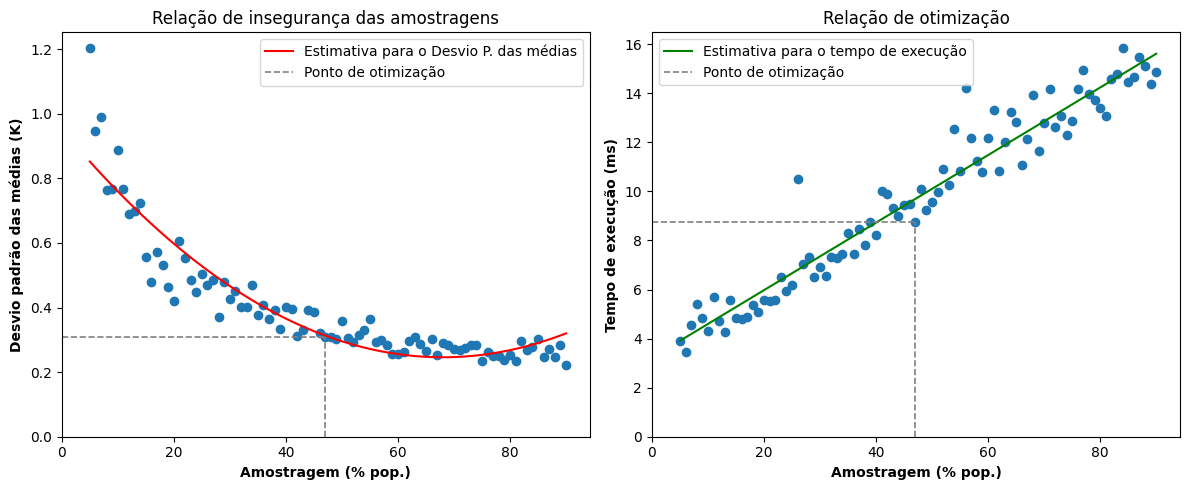

In [115]:
import matplotlib.pyplot as plt

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

# Plotagem de dados do desvio padrão
eixos[0].set_xlabel("Amostragem (% pop.)", fontweight="bold")
eixos[0].set_ylabel("Desvio padrão das médias (K)", fontweight="bold")
eixos[0].set_title("Relação de insegurança das amostragens");

eixos[1].set_xlabel("Amostragem (% pop.)", fontweight="bold")
eixos[1].set_ylabel("Tempo de execução (ms)", fontweight="bold")
eixos[1].set_title("Relação de otimização")

# Plotagem de pontos dos dados
eixos[0].scatter(
    x=dfa3["Amostragem (% pop.)"],
    y=dfa3["Desvio Padrão das Médias (K)"]
    )

eixos[1].scatter(
    x=dfa3["Amostragem (% pop.)"],
    y=dfa3["Tempo de execução (ms)"]
)

# Plotando linhas de regressão
eixos[0].plot(x.values.ravel(), dpm_previsto, color="red", label="Estimativa para o Desvio P. das médias")
eixos[1].plot(x.values.ravel(), tempo_previsto, color="green", label="Estimativa para o tempo de execução")

# Limites para o gráfico
eixos[0].set(xlim=0, ylim=0)
eixos[1].set(xlim=0, ylim=0)

# Linhas para o ponto mais otimizado
tempo_otimizado = menor_amostragem_satisfatoria["Tempo de execução (ms)"]
eixos[0].hlines(y=0.31, xmin=0, xmax=47, color="gray", linestyle="--", linewidth=1.2, label="Ponto de otimização")
eixos[0].vlines(x=47, ymin=0, ymax=0.31, color="gray", linestyle="--", linewidth=1.2)

eixos[1].hlines(y=tempo_otimizado, xmin=0, xmax=47, color="gray", linestyle="--", linewidth=1.2, label="Ponto de otimização")
eixos[1].vlines(x=47, ymin=0, ymax=tempo_otimizado, color="gray", linestyle="--", linewidth=1.2)

# Inserindo legendas
eixos[0].legend()
eixos[1].legend()

# Ajusta espaçamento
plt.tight_layout()
plt.show();

O comportamento assintótico observado no gráfico da relação de incerteza ocorre em razão da aproximação do desvio padrão das médias ao erro padrão médio, o qual é inversamente proporcional à raiz quadrada do tamanho da amostra. Já o segundo gráfico revela a importância de buscar a otimização: o tempo de execução cresce conforme a reta $t(n) =  0.14n + 3.22$, em milissegundos. Destacado pelas linhas tracejadas, estão os pontos correspondentes ao ponto de maior otimização.

## Conclusão

Portanto, o valor teórico para o $\text{EPM}$ pode ser estimado pelo cálculo do desvio padrão das médias de amostragens aleatórias de mesmo tamanho. Ou seja, o $\text{EPM}$ é uma ferramenta poderosa e rápida para avaliar a precisão da estiamtiva a respeito da população. Aliado a isso, o $\text{EPR}$ fornece uma maneira em porcentagem para visualizar esse dado, podendo ser comparado entre diferentes parâmetros. 

Desse modo, o tamanho mais adequado de uma amostra para determinado cenário pode ser definido por meio dessas métricas, permitindo que inferências sejam feitas de maneira mais segura e dentro de critérios especificados.

## Uso de IA neste trabalho

- Configuração de gráficos;
- Configuração de pandas;
- Dúvidas com detalhes de código (time, docstring, dicionário...)
- Esclarecimento sobre diferenciação de termos estatísticos;
- Geração da docstring para a função principal;
- Busca de referências. 

## Referências

[1] GEEKSFORGEEKS. **Population vs Sample in Statistics**. GeeksforGeeks, 15 jun. 2026. Disponível em: https://www.geeksforgeeks.org/maths/population-and-sample-statistics/. Acesso em: 22 ago. 2026.

[2] HAMIDIEH, Kam. **Superconductivty Data**. Irvine: UCI Machine Learning Repository, 2018. Dataset. Disponível em: https://doi.org/10.24432/C53P47. Acesso em: 22 ago. 2026.

[3] Bardeen, J., Cooper, L. N., & Schrieffer, J. R. (1957). **Theory of Superconductivity**. Physical Review, 108(5), 1175–1204 https://journals.aps.org/pr/pdf/10.1103/PhysRev.108.1175

[4] STATISTICS HOW TO. **Bessel's correction: why use N-1 for variance/standard deviation?** [S. l.], [20--?]. Disponível em: https://www.statisticshowto.com/bessels-correction/. Acesso em: 22 ago. 2026.

[5]  BHANDARI, Pritha. **What is standard error? How to calculate (guide with examples)**. Scribbr, 11 dez. 2020. Disponível em: https://www.scribbr.com/statistics/standard-error/. Acesso em: 22 ago. 2026.

[6] GEEKSFORGEEKS. **Relative Standard Error**. GeeksforGeeks, 23 jul. 2025. Disponível em: https://www.geeksforgeeks.org/maths/relative-standard-error/. Acesso em: 22 ago. 2026.

<div style="width: 100%; text-align: center; margin-bottom: 20px;">
  <img src="rodape_eleicao.png" alt="Rodapé" style="max-width: 100%; height: auto;">
</div>